<a href="https://colab.research.google.com/github/MicheleQGF/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print('Cantidad de valores nulos en Users', users.isna().sum())# Cantidad de valores nulos
print('Proporción de valores nulos en Users', users.isna().mean())# Proporción de valores nulos)


Cantidad de valores nulos en Users user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos en Users user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print('Cantidad de valores nulos en Usage', usage.isna().sum())# Cantidad de valores nulos
print('Proporción de valores nulos en Usage', usage.isna().mean())# Proporción de valores nulos)

Cantidad de valores nulos en Usage id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos en Usage id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Users 4,000 registros**:
- city tiene casi el 12% de valores nulos, tenemos que averiguar si es un caso de MAR o MNAR
- churn_date tiene el 88% de valores nulos y no es claro si el que no haya fecha de abandono quiere decir que continúan con el plan. Aunque para las preguntas que debemos contestar no parece relevante entonces los ignoraremos
- las fechas se deben formatear correctamente

**Usage 40,000 registros**:
- las fechas se deben formatear correctamente
- el 0.125% de las fechas faltan, podemos imputar si es necesario
- duration (55% de valores nulos) y length(44% de valores nulos) parecen referirse a distintos tipos de comunicación, llamada y texto respectivamente.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene una variación estándar alta, esperamos ese resultado por que esperamos usuarios únicos
- La columna `age` tiene sentinelas y valores imposibles que hay que eliminar, el valor máximo es posible

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`tienen una variación estándar alta lo que es de esperarse. Asumimos que user_id corresponde a la user_id de users puesto que sus valores son idénticos
- Las columnas `duration` y `length`tienen una variación estándar posible de una llamada o texto

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` tiene valores nulos y valores centinela (?) que hay que limpiar, sin embargo el conteo de ? en Básico y Premium sin registro de ciudad, no corresponde al conteo de nulos de city
- La columna `plan` cuenta con los dos nombres de los planes y cada ciudad tiene ambos registros

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()# completa el código

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene sólo 2 tipos de registros sin nulos aunque el número de registros no coincide con los conteos de registros de duration y length

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
---

- Hay valores inválidos en la columna age de users que podemos imputar con la media de las edades una vez que quitemos estos sentinelas
- Hay nulos y valores inválidos en la columna city de users, hay que ver si se trata de un MAR o MNAR y si no tal vez eliminarlos será la opción?

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")# completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] =  pd.to_datetime(usage['date'], errors="coerce")# completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

En `reg_date`, hay registros de una fecha que todavía no ocurre (2026-05-10), son registros inválidos, hay 3961 fechas únicas, lo más probable sea que el error se repite 40 veces

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

En `date`, vemos que las llamadas se hicieron entre Enero y Junio de 2024, ninguna se repite

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---
Aparece la fecha 2026_05_10 40 veces como año de registro de usuarios, es una fecha que aún no transcurre por lo que es inválida, pero para las preguntas de negocio que estamos intentando responder, son irrelevantes entonces las podemos dejar como NaN

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
Invalid_Reg_Date = pd.to_datetime('2026-05-10 00:00:00.000000000')
users['reg_date'] = users['reg_date'].where(users['reg_date'] != Invalid_Reg_Date, pd.NA)
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Los registros de `duration` son todos de tipo call puesto que todos los nulos están en el tipo text y al contrario los registros de `length` son de tipo text, quiere decir que ambas columnas se refieren a tipos diferentes de datos por lo tanto debemos dejarlas y tratarlas como tal

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id', dropna=False).agg({'is_call':'sum','is_text': 'sum', 'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_call,is_text,duration
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_call': 'cant_llamadas', 'is_text': 'cant_mensajes', 'duration': 'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on = 'user_id', how = 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
#user_profile_2 = user_profile.dropna(subset = ['cant_minutos_llamada'])
user_profile.describe()

,user_id,age,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,4.478120,5.524381,23.317054
std,1154.844867,17.690408,2.144238,2.358416,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,3.000000,4.000000,11.120000
50%,11999.500000,47.000000,4.000000,5.000000,19.780000
75%,12999.250000,63.000000,6.000000,7.000000,31.415000
max,13999.000000,79.000000,15.000000,17.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

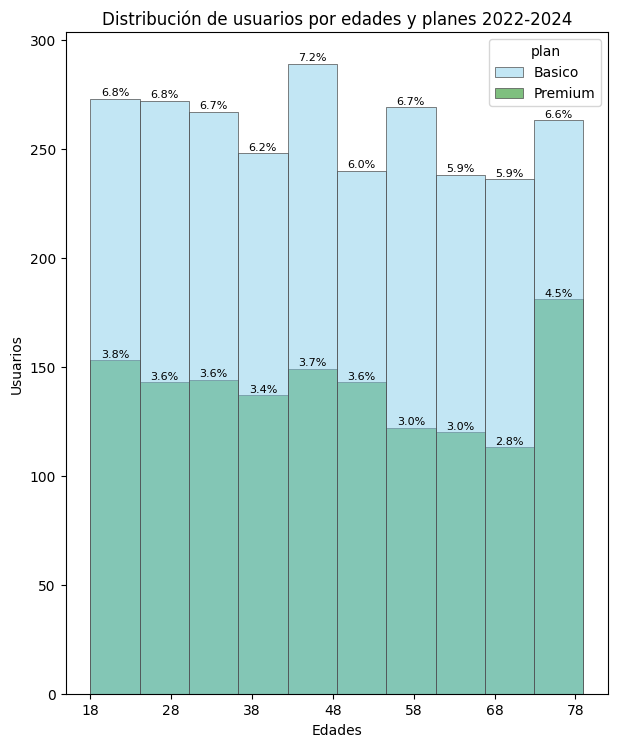

In [ ]:


# Histograma para visualizar la edad (age)
plt.figure(figsize=(7, 3.5))
# Calcular porcentajes para cada plan
total_usuarios = len(user_profile)
plt.subplots_adjust(top=2)
ax = sns.histplot(
    user_profile,
    x = 'age',
    bins = 10,
    hue = 'plan',
    palette = ['skyblue','green'],
    edgecolor= '.3',
    linewidth=.5
)

# Obtener información de las barras y agregar etiquetas
for container in ax.containers:
    # Iterar sobre cada barra en el contenedor
    for bar in container:
        height = bar.get_height()
        if height > 0:  # Solo agregar etiqueta si hay datos
            # Calcular porcentaje
            percentage = (height / total_usuarios) * 100
            # Agregar texto encima de la barra
            ax.text(
                bar.get_x() + bar.get_width()/2,  # Posición x (centro de la barra)
                height + 0.5,                     # Posición y (encima de la barra)
                f'{percentage:.1f}%',             # Texto del porcentaje
                ha='center',                      # Alineación horizontal
                va='bottom',                      # Alineación vertical
                rotation=0,                      # Rotación del texto
                fontsize=8                        # Tamaño de fuente
            )

plt.xticks(range(18,80,10))
plt.title('Distribución de usuarios por edades y planes 2022-2024')
plt.ylabel('Usuarios')
plt.xlabel('Edades')
plt.show()




💡Insights:
- El histograma es plano, la distribución de las edades es bastante esparcida, tal vez con un segmento de personas que destaca al rededor de los 46-48 años

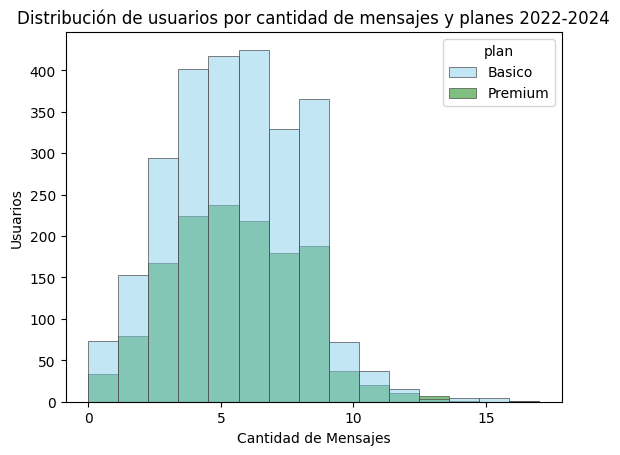

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    user_profile,
    x = 'cant_mensajes',
    bins = 15,
    hue = 'plan',
    palette = ['skyblue','green'],
    edgecolor= '.3',
    linewidth=.5
)
plt.xticks(range(0,17,5))
plt.title('Distribución de usuarios por cantidad de mensajes y planes 2022-2024')
plt.ylabel('Usuarios')
plt.xlabel('Cantidad de Mensajes')
plt.show()


💡Insights:
- Hay sesgo a la derecha, las cantidades de mensajes por usuario son menos de diez

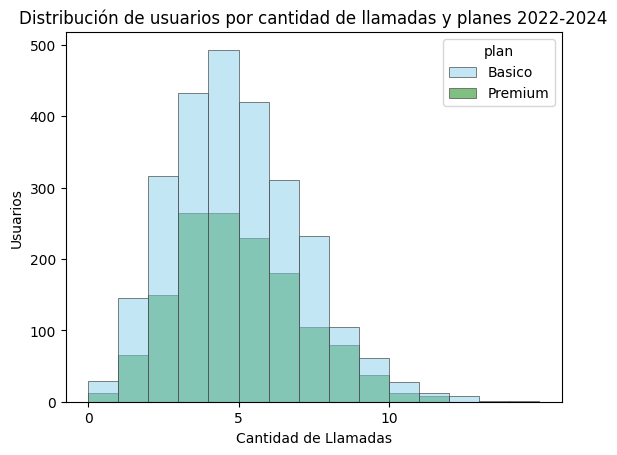

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    user_profile,
    x = 'cant_llamadas',
    bins = 15,
    hue = 'plan',
    palette = ['skyblue','green'],
    edgecolor= '.3',
    linewidth=.5
)
plt.xticks(range(0,15,5))
plt.title('Distribución de usuarios por cantidad de llamadas y planes 2022-2024')
plt.ylabel('Usuarios')
plt.xlabel('Cantidad de Llamadas')
plt.show()

💡Insights:
- Distribución sesgada a la derecha, la cantidad de llamadas más frecuentes de llamadas por usuario rondan al rededor de 5

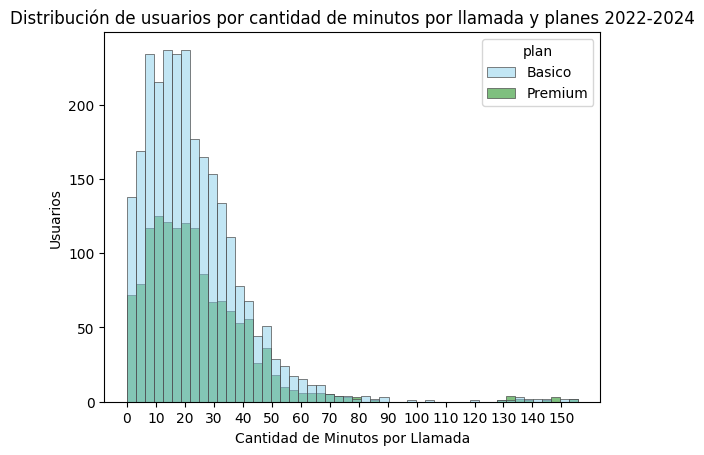

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    user_profile,
    x = 'cant_minutos_llamada',
    bins = 50,
    hue = 'plan',
    palette = ['skyblue','green'],
    edgecolor= '.3',
    linewidth=.5
)
plt.xticks(range(0,156,10))
plt.title('Distribución de usuarios por cantidad de minutos por llamada y planes 2022-2024')
plt.ylabel('Usuarios')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.show()

💡Insights:
- Hay un claro sesgo a la derecha, la frecuencia de llamadas es de menos de una hora auqnue hay un pequeño grupo de usuarios que hace llamadas largas de 130 a 156 minutos por llamada relativamente frecuentes

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

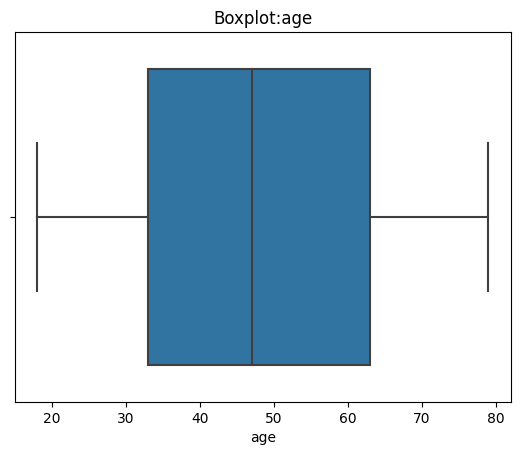

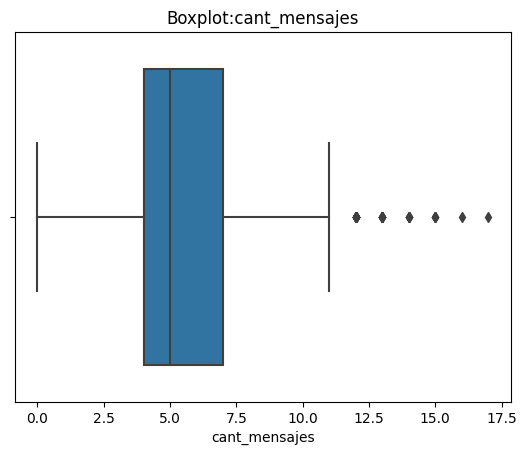

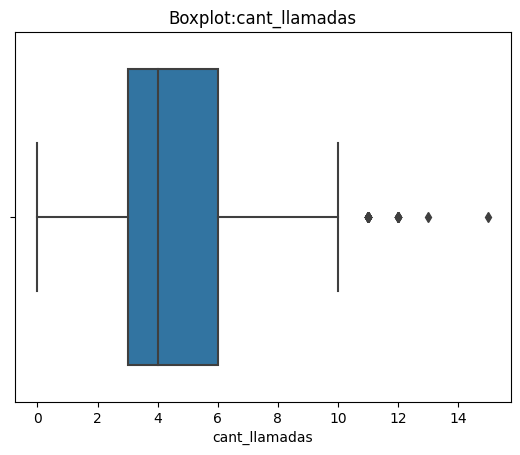

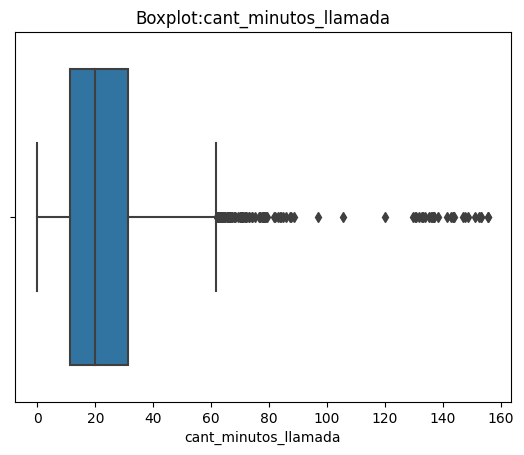

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x= user_profile[col])
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights:
- Age: No presenta outliers, las edades están distribuídas entre 18 y 79 años
- cant_mensajes: Presenta outliers, aunque tal vez no son relevantes
- cant_llamadas: Presenta outliers, aunque tal vez no son relevantes
- cant_minutos_llamada: Presenta muchos outliers y tal vez hay un grupo de alto valor en ellos

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    #limites para outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    #outliers = user_profile[(user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)]
    print (f'Limite Inferior:{col}', limite_inferior)
    print (f'Limite Superior:{col}', limite_superior)
    print (f'IQR:{col}', IQR)
    #print (f'outliers:{col}', outliers)



Limite Inferior:cant_mensajes -0.5
Limite Superior:cant_mensajes 11.5
IQR:cant_mensajes 3.0
Limite Inferior:cant_llamadas -1.5
Limite Superior:cant_llamadas 10.5
IQR:cant_llamadas 3.0
Limite Inferior:cant_minutos_llamada -19.322500000000005
Limite Superior:cant_minutos_llamada 61.8575
IQR:cant_minutos_llamada 20.295


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Capar los outliers me parece una opción porque no son extremos pero modifican el promedio y estamos buscando analizar tendencias centrales en los comportamientos de los usuarios
- cant_llamadas: Capar los outliers me parece una opción porque no son extremos pero modifican el promedio y estamos buscando analizar tendencias centrales en los comportamientos de los usuarios
- cant_minutos_llamada: mantener los outliers me parece la opción porque son muchos outliers y son muy extremos, más del doble del límite alto, podrían ser clientes de alto valor o líneas que se quedaron abiertas

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# Función para clasificar clientes por cantidades de mensajes y llamadas
def segmento_uso(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    # Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"

    # Segmentación de Bajo Uso (mensajes < 5 , llamadas < 5)
    if  mensajes < 5 and llamadas < 5:
        return 'Uso Bajo'

    # Segmentación de Uso Medio (mensajes < 10, llamadas < 10)
    elif mensajes < 10 and llamadas < 10:
        return 'Uso Medio'

    # Segmentación de Uso Alto (mensajes > 10, llamadas >10)
    else:
        return 'Uso Alto'

# aplicar función
user_profile['grupo_uso'] = user_profile.apply(segmento_uso, axis = 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,Uso Medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,Uso Alto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,Uso Medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,Uso Alto
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,Uso Bajo


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
# Función para clasificar clientes por edad
def segmento_edad(row):
    edad = row['age']

    # Manejo de valores nulos/faltantes
    # pd.isna() verifica de forma robusta si el valor es NaN
    if pd.isna(edad):
        return "Error en Datos"

    # Segmentación usuarios jóvenes (age < 30)
    if  edad < 30:
        return 'Joven'

    # Segmentación de usuarios adultos (age < 60)
    elif edad < 60:
        return 'Adulto'

    # Segmentación de usuarios adulto mayor (age > 60)
    else:
        return 'Adulto Mayor'

# aplicar función
user_profile['grupo_edad'] = user_profile.apply(segmento_edad, axis = 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,Uso Medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,Uso Alto,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,Uso Medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,Uso Alto,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,Uso Bajo,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

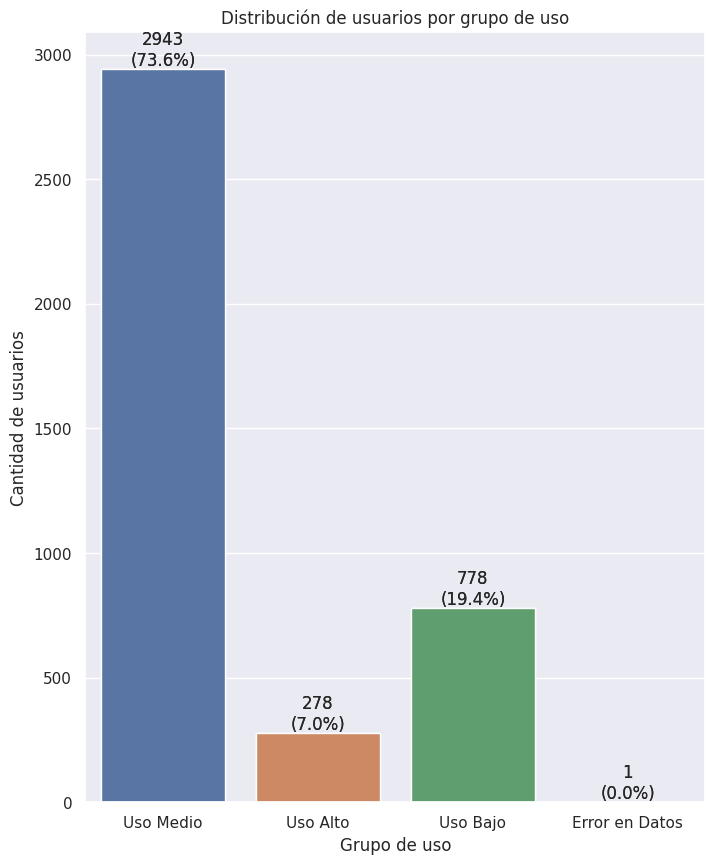

In [ ]:

# Visualización de los segmentos por uso
plt.figure(figsize=(8, 10))
ax = sns.countplot(data=user_profile, x='grupo_uso')
# Calcular total para porcentajes
total = len(user_profile)
sns.countplot(data=user_profile, x='grupo_uso')
# Poner los números correspondientes a cada barra
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100*count/total:.1f}%'
    ax.annotate(f'{count}\n({percentage})',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()


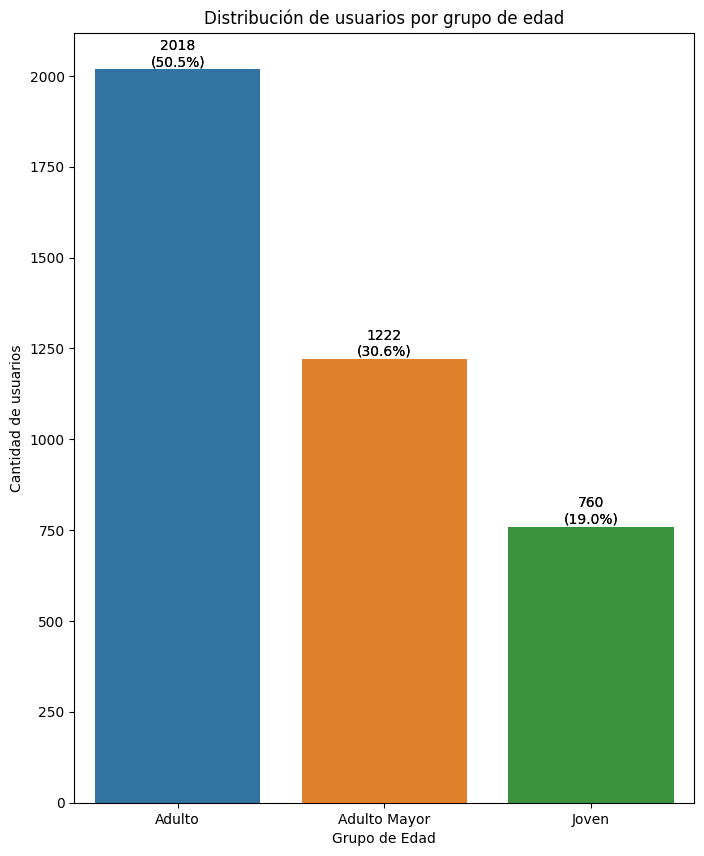

In [ ]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 10))
ax = sns.countplot(data=user_profile, x='grupo_edad')
sns.countplot(data=user_profile, x='grupo_edad')
# Poner los números correspondientes a cada barra
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100*count/total:.1f}%'
    ax.annotate(f'{count}\n({percentage})',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [ ]:
#crear una tabla para visualizar un heatmap
user_profile_2 = user_profile.groupby(['age', 'cant_llamadas'])['cant_minutos_llamada'].mean().reset_index()
user_profile_2 = user_profile_2.pivot(index="cant_llamadas", columns="age", values="cant_minutos_llamada")
user_profile_2.head()


age,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,...,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0,78.0,79.0
cant_llamadas,,,,,,,,,,,,,,,,,,,,,
0.0,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,NaN,NaN,NaN,0.000000,0.0000,NaN,NaN,0.000000
1.0,6.300000,2.513333,2.594000,6.826667,1.680000,4.970000,4.466667,10.780000,26.262000,4.003333,...,3.220,3.945000,4.568333,9.413333,11.086667,6.354000,2.2475,3.203333,2.723333,1.326667
2.0,6.511111,16.854615,8.885714,10.440000,6.821667,12.013333,10.119000,16.302857,11.608462,6.116000,...,6.180,6.453333,9.405000,7.642000,10.580000,9.994444,12.7600,12.127000,6.576667,6.011667
3.0,13.565000,14.337000,12.103333,13.660000,18.050000,16.937273,13.880000,20.078750,11.690000,17.323000,...,15.320,16.476364,14.818571,15.392500,27.698889,11.333750,15.0000,13.484444,14.248750,14.362727
4.0,34.734444,18.766364,14.576364,17.357500,20.367857,28.695625,25.261429,18.202353,16.872667,16.842222,...,28.133,21.546111,18.519167,22.554286,17.115833,14.453077,26.3350,21.073333,19.098125,25.681538


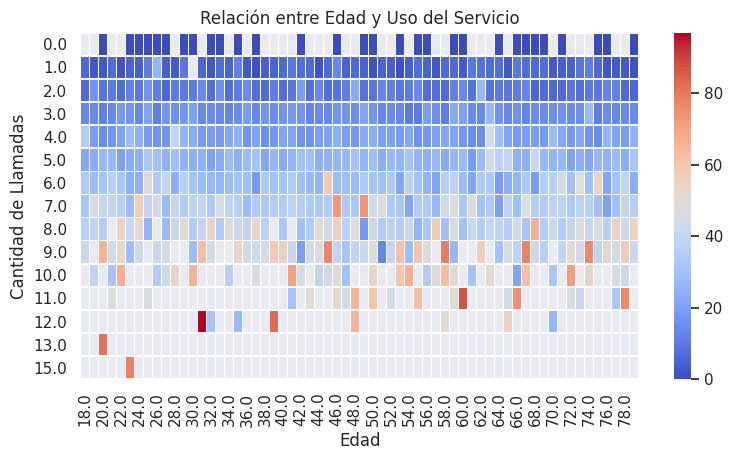

In [ ]:

#heatmap para visualizar Edad contra la cantidad de llamadas
plt.figure(figsize=(9, 4.5))
sns.heatmap(user_profile_2, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Relación entre Edad y Uso del Servicio')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Llamadas')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Datos faltantes en users:
  - churn date: 88.3% no es claro si esa falta de fecha son los usuarios que no han abandonado su plan
  - city: 11.7%
- Datos flatantes en usage:
  - Date: 0.1%
  - Duration (55.1%) y Length (44.7%) corresponden a llamadas y texto respectivamente
- Fechas fuera de formato que se formatearon
- Valores imposibles/Sentinelas en age y city en users que se cambiaron por NaN
- 40 registros de una fecha de registro que no ha ocurrido aún, 2026-05-10 que se cambió por NA
- Al final sólo hay 3999 registros de Duration y Length en usage en total contra 4000 user_ids, un registro vacío se dejó pero no es relevante
- Datos del análisis quedaron con fechas de 2022-2024

🔍 **Segmentos por Edad**
- 50.5% de los usuarios son Adultos entre 30 y 60 años
- 30.6% de los usuarios son Adultos Mayores arriba de 60 años
- 19% de los usuarios son Jóvenes entre 18 y 30 años
- Podemos decir que los usuarios de planes Premium son prácticamente en todas las edades la mitad de los usuarios de planes Básico


📊 **Segmentos por Nivel de Uso**
- 73.6% de los usuarios son de uso medio, es decir que hacen entre 5 y 10 llamadas y envían entre 5 y 10 mensajes
- 19.4 % de los usuarios son de uso bajo, es decir que hacen menos de 5 llamadas y envían menos de 5 mensajes
- 7% de los usuarios son de uso alto, es decir que hacen más de 10 llamadas y envían más de 10 mensajes
- Realicé un heatmap extra para revisar si los números altos en la cantidad de minutos por llamada podían relacionarse con algún segmento de edad claro pero están repartidos por todas las edades


➡️ Esto sugiere que ...

- ConnectaTel tiene una base de usuarios madura y estable pero podría estar ocultando fugas de ingresos o riesgos de abandono por una falta de conexión entre el comportamiento de los usuarios y la oferta comercial de la empresa.
- El análisis se centra en llamadas y mensajes tradicionales por lo que la mayoría de los usuarios son adultos y adultos mayores, sólo el 19% son usuarios jóvenes.
- Los usuarios adultos (50.5%), de uso medio (73.6%) y de plan premium son los usuarios más valiosos porque su comportamiento es predecible y su satisfacción depende de la estabilidad de la red, no de ofertas llamativas.
- El segmento de bajo uso pueden ser líneas secundarias o usuarios de prepago mínimo.
- El segmento de mayor uso no parece estar relacionado con un segmento de edad particular al menos en cuanto a llamadas tradicionales, los usuarios jóvenes tienden a ocupar más el internet que las llamadas y mensajes tradicionales pero nos hacen falta los datos de uso del internet en los usuarios, o datos de facturación para saber si los usuarios jóvenes facturan mucho por el uso de internet.


💡 **Recomendaciones**
- los usuarios de uso bajo necesitarían un plan de "pago por uso" o un paquete básico para evitar que cancelen la línea por falta de uso para evitar el abandono. Pero los usuarios premium de uso bajo podrían estar sobrepagando porque no usan el servicio, habría que proponerles otro plan para que no abandonen
- los usuarios de uso medio y plan básico están siendo desaprovechados, podrían estar al límite de su capacidad.
- los usuarios adultos mayores de uso medio que están en básico necesitan un plan de fidelización, ofertas de "Números frecuentes" o asistencia técnica prioritaria, ya que valoran más el servicio al cliente.
- los de uso alto requerirían migrarse a planes "Ilimitados" o empresariales para aumentar el ticket promedio y monitorear comportamiento inusual. Los que están en Básico están consumiendo más de lo que pagan.
- Creación de un plan Intermedio: El 73.6% de tus usuarios son de uso medio. Con sólo un plan Básico y uno Premium, se está obligando a la mayoría a elegir algo que les queda "chico" o algo que les queda "muy grande". Un plan optimizado para este 73% aumentaría la satisfacción.
- Buscar ganar más usuarios jóvenes con paquetes basados en datos es necesario para la supervivencia y el crecimiento a largo plazo. Crear un plan basado en Datos dirigido al segmento de Jóvenes dentro del grupo de Uso Medio que están en Plan Básico y ofrécerles el Premium no por las llamadas (que no usan tanto), sino por un paquete de datos ilimitados o redes sociales, con programas de recompensas por puntualidad en el pago o por invitar amigos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`